In [1]:
# import warnings is simply used to remove warnings about incompatibility with future Pandas update on Nate's device
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
from EL_func_run_all_functions import *
import pandas as pd
from ipynb.fs.defs.EL_working_file import (construct_calendar_year_list, 
                                            construct_business_case_year_list, 
                                            construct_operations_years_list, 
                                            construct_decomissioning_years_list, 
                                            construction_phase,
                                            operational_phase,
                                            decommissioning_phase,
                                            taxes_and_profits_part1,
                                            debt_and_loan_part1,
                                            taxes_and_profits_part2,
                                            debt_and_loan_part2,
                                            project_reserves,
                                            equity_funding,
                                            present_value_cashflows,
                                            cumulative_equity_and_debt_cashflows,
                                            discounted_cashflows_for_levelized_cost,
                                            levelized_cost_and_revenues,
                                            project_kpi,
                                            equity_kpi,
                                            output_kpi)
from OWF_input_data import *
import importlib
import EL_input_data
from NSE_get_data_from_ESDL import *

XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
electricity sold =    Pessimistic  Most likely  Optimistic
0    3578960.0    3578960.0   3578960.0 MWh
hydrogen sold =     Pessimistic   Most likely    Optimistic
0  1.824252e+06  1.824252e+06  1.824252e+06 MWh
electricity sold =    Pessimistic  Most likely  Optimistic
0    3578960.0    3578960.0   3578960.0 MWh
hydrogen sold =     Pessimistic   Most likely    Optimistic
0  1.824252e+06  1.824252e+06  1.824252e+06 MWh
electricity sold =    Pessimistic  Most likely  Optimistic
0    3578960.0    3578960.0   3578960.0 MWh
hydrogen sold =     Pessimistic   Most likely    Optimistic
0  1.824252e+06  1.824252e+06  1.824252e+06 MWh
All variables saved to Operation_Analysis_variables.pkl


Run the levelized cost and revenues function for all scenarios

In [ ]:


file_names = ["TNVDW_cost_single_units_v1_pessimistic_scenario.esdl", "TNVDW_cost_single_units_v1_most_likely_scenario.esdl", "TNVDW_cost_single_units_v1_optimistic_scenario.esdl"]

# make a dataframe that will contain the levelized costs and revenues from all scenarios    
# Define the levels of the MultiIndex
groups = ['Pessimistic', 'Most likely', 'Optimistic']  # Group names
sub_columns = ['Costs', 'Revenues']  # Sub-column names

# Create the MultiIndex from the groups and sub_columns
multi_index = pd.MultiIndex.from_product([groups, sub_columns], names=['Scenario', 'Type'])

# Create an empty DataFrame with the multi-level columns
df_lcr_all_scenarios = pd.DataFrame(columns=multi_index)

# Make a dataframe that will contain all kpi results
df_kpi_results = pd.DataFrame(columns=['Pessimistic', 'Most likely', 'Optimistic', 'Unit'])


for x in file_names:

    esh = EnergySystemHandler()
    esh.load_file(x)
    energy_system = esh.get_energy_system()
    instance_list = energy_system.instance
    my_instance = instance_list[0]

    if x == file_names[0]:
        drop_scenarios = ['most_likely','optimistic']
    elif x == file_names[1]:
        drop_scenarios = ['pessimistic','optimistic']
    else: 
        drop_scenarios = ['pessimistic','most_likely']
    
    save_to_pickle(drop_scenarios, asset_parameters)

    importlib.reload(EL_input_data)


    el_run_all_functions(EL_input_data.el_capex_100mw,
                         EL_input_data.df_el_opex_100mw,
                         EL_input_data.el_inflation,
                         EL_input_data.el_annual_electricity_costs_ppa,
                         EL_input_data.el_annual_electricity_costs_grid,
                         EL_input_data.el_electricity_grid_connection,
                         EL_input_data.el_h2_storage_costs,
                         EL_input_data.df_stack_replacement_100mw,
                         EL_input_data.el_h2_revenues,
                         EL_input_data.el_hwi_revenues,
                         EL_input_data.el_decommissioning_percentage,
                         EL_input_data.el_loan_percentage,
                         EL_input_data.el_loan_interest_rate,
                         EL_input_data.el_income_tax_rate,
                         EL_input_data.el_general_wacc,
                         EL_input_data.el_lifetime)


    levelized_cost = levelized_cost_and_revenues(EL_input_data.el_capex_100mw,
                                                EL_input_data.df_el_opex_100mw,
                                                EL_input_data.el_inflation,
                                                EL_input_data.el_annual_electricity_costs_ppa,
                                                EL_input_data.el_annual_electricity_costs_grid,
                                                EL_input_data.el_electricity_grid_connection,
                                                EL_input_data.el_h2_storage_costs,
                                                EL_input_data.df_stack_replacement_100mw,
                                                EL_input_data.el_h2_revenues,
                                                EL_input_data.el_hwi_revenues,
                                                EL_input_data.el_decommissioning_percentage,
                                                EL_input_data.el_loan_percentage,
                                                EL_input_data.el_loan_interest_rate,
                                                EL_input_data.el_income_tax_rate,
                                                EL_input_data.el_general_wacc,
                                                EL_input_data.el_lifetime)

    project_result = project_kpi(EL_input_data.el_capex_100mw,
                                EL_input_data.df_el_opex_100mw,
                                EL_input_data.el_inflation,
                                EL_input_data.el_annual_electricity_costs_ppa,
                                EL_input_data.el_annual_electricity_costs_grid,
                                EL_input_data.el_electricity_grid_connection,
                                EL_input_data.el_h2_storage_costs,
                                EL_input_data.df_stack_replacement_100mw,
                                EL_input_data.el_h2_revenues,
                                EL_input_data.el_hwi_revenues,
                                EL_input_data.el_decommissioning_percentage,
                                EL_input_data.el_loan_percentage,
                                EL_input_data.el_loan_interest_rate,
                                EL_input_data.el_income_tax_rate,
                                EL_input_data.el_general_wacc,
                                EL_input_data.el_lifetime)   

    equity_result = equity_kpi(EL_input_data.el_capex_100mw,
                                EL_input_data.df_el_opex_100mw,
                                EL_input_data.el_inflation,
                                EL_input_data.el_annual_electricity_costs_ppa,
                                EL_input_data.el_annual_electricity_costs_grid,
                                EL_input_data.el_electricity_grid_connection,
                                EL_input_data.el_h2_storage_costs,
                                EL_input_data.df_stack_replacement_100mw,
                                EL_input_data.el_h2_revenues,
                                EL_input_data.el_hwi_revenues,
                                EL_input_data.el_decommissioning_percentage,
                                EL_input_data.el_loan_percentage,
                                EL_input_data.el_loan_interest_rate,
                                EL_input_data.el_income_tax_rate,
                                EL_input_data.el_general_wacc,
                                EL_input_data.el_lifetime)

    output_result = output_kpi(EL_input_data.el_capex_100mw,
                            EL_input_data.df_el_opex_100mw,
                            EL_input_data.el_inflation,
                            EL_input_data.el_annual_electricity_costs_ppa,
                            EL_input_data.el_annual_electricity_costs_grid,
                            EL_input_data.el_electricity_grid_connection,
                            EL_input_data.el_h2_storage_costs,
                            EL_input_data.df_stack_replacement_100mw,
                            EL_input_data.el_h2_revenues,
                            EL_input_data.el_hwi_revenues,
                            EL_input_data.el_decommissioning_percentage,
                            EL_input_data.el_loan_percentage,
                            EL_input_data.el_loan_interest_rate,
                            EL_input_data.el_income_tax_rate,
                            EL_input_data.el_general_wacc,
                            EL_input_data.el_lifetime)

    # create a temporary column of dummy data at the top-level of the MultiIndex (which will later be dropped)
    # without first creating this temporary column, pandas will not be able to assign values to the MultiIndex df
    df_lcr_all_scenarios.loc[:, 'temp'] = levelized_cost['cost']

    if x == file_names[0]:
        # add to pessimistic
        df_lcr_all_scenarios.loc[:, ('Pessimistic','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Pessimistic','Revenues')] = levelized_cost['revenues'] 

        project_result_pes = project_result.drop(columns=['Unit'])
        project_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)
        equity_result_pes = equity_result.drop(columns=['Unit'])
        equity_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)
        output_result_pes = output_result.drop(columns=['Unit'])
        output_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)

    elif x == file_names[1]:
        # add to most_likely
        df_lcr_all_scenarios.loc[:, ('Most likely','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Most likely','Revenues')] = levelized_cost['revenues']

        project_result_ml = project_result.drop(columns=['Unit'])
        project_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)
        equity_result_ml = equity_result.drop(columns=['Unit'])
        equity_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)
        output_result_ml = output_result.drop(columns=['Unit'])
        output_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)

    else: 
        # add to optimistic
        df_lcr_all_scenarios.loc[:, ('Optimistic','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Optimistic','Revenues')] = levelized_cost['revenues']

        project_result_opt = project_result
        project_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)
        equity_result_opt = equity_result
        equity_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)
        output_result_opt = output_result
        output_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)

df_project_kpi_results = pd.concat([project_result_pes, project_result_ml, project_result_opt], axis=1)
df_equity_kpi_results = pd.concat([equity_result_pes, equity_result_ml, equity_result_opt], axis=1)
df_output_kpi_results = pd.concat([output_result_pes, output_result_ml, output_result_opt], axis=1)

project_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Project KPI's"])
equity_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Equity KPI's"])
output_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Output KPI's"])

df_project_kpi_results = pd.concat([project_kpi_row, df_project_kpi_results], axis=0)
df_equity_kpi_results = pd.concat([equity_kpi_row, df_equity_kpi_results], axis=0)
df_output_kpi_results = pd.concat([output_kpi_row, df_output_kpi_results], axis=0)

df_kpi_results = pd.concat([df_project_kpi_results, df_equity_kpi_results, df_output_kpi_results], axis=0)

#return to most likely scenario
drop_scenarios = ['pessimistic','optimistic']
save_to_pickle(drop_scenarios, asset_parameters)  

# drop temporary column that was only used for correct multi-level dataframe assignment        
df_lcr_all_scenarios = df_lcr_all_scenarios.drop(columns='temp')

df_lcr_all_scenarios

XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
All variables saved to NSE_get_data_from_ESDL.pkl


C:\Users\DinaBoer\AppData\Local\Temp\ipykernel_21868\2295631808.py:183: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_lcr_all_scenarios = df_lcr_all_scenarios.drop(columns='temp')


Scenario                    Pessimistic             Most likely              \
Type                              Costs    Revenues       Costs    Revenues   
capex                        249.264738         0.0  133.228979         0.0   
opex                         153.922196         0.0   89.528547         0.0   
purchase_electricity_ppa      73.282208         0.0   56.069565         0.0   
purchase_electricity_grid     12.961826         0.0     9.42917         0.0   
electricity_grid_connection   19.640697         0.0   20.087766         0.0   
h2_storage_costs               0.956481         0.0    1.381003         0.0   
stack_replacement             82.943356         0.0   45.816732         0.0   
decommissioning                2.097438         0.0    0.786244         0.0   
interest_costs                71.053153         0.0   16.570293         0.0   
contingency                   26.722785         0.0   14.884046         0.0   
tax_expenses                       -0.0         0.0    5.721349         0.0   
h2_revenues                         0.0   78.794618         0.0   71.913534   
hwi_revenues                        0.0  187.787969         0.0  193.562958   
profits                             0.0         0.0         0.0         0.0   
unprofitable_gap                    0.0   426.26229         0.0    128.0272   

Scenario                    Optimistic              
Type                             Costs    Revenues  
capex                        59.008617         0.0  
opex                         21.973574         0.0  
purchase_electricity_ppa      55.45203         0.0  
purchase_electricity_grid     8.099614         0.0  
electricity_grid_connection  21.032239         0.0  
h2_storage_costs              1.587727         0.0  
stack_replacement            28.084523         0.0  
decommissioning                0.51781         0.0  
interest_costs                3.305986         0.0  
contingency                   6.113787         0.0  
tax_expenses                 29.780124         0.0  
h2_revenues                        0.0   76.228559  
hwi_revenues                       0.0  204.234802  
profits                       45.50733         0.0  
unprofitable_gap                   0.0         0.0

All KPI's results

In [4]:
def clean_index_name(index):
    index = index.replace("_", " ")  # Replace underscores with spaces
    index = index.capitalize()  # Capitalize the first letter
    index = index.replace("kpi's", "KPI's")
    index = index.replace("EUR", "€")
    return index

# Apply the function to each index name
new_index_names = {index: clean_index_name(index) for index in df_kpi_results.index}

# Rename the index using the dictionary
df_kpi_results.rename(index=new_index_names, inplace=True)

# Change EUR to €
df_kpi_results['Unit'] = df_kpi_results['Unit'].replace({'Eur/MWh': '€/MWh', 'MEUR': '€'})

# Display the cleaned-up DataFrame
df_kpi_results.style.format(precision=2)


,Pessimistic,Most likely,Optimistic,Unit
Project KPI's,,,,
Net present value,-4022.10,-1191.34,1565.28,€
Internal rate of return,nan,-1.05,16.64,%
Return on investment,-249.83,-48.44,412.55,%
Payback period,-8.01,-51.61,7.27,years
Discounted return on investment,-130.94,-67.60,144.43,%
Discounted payback period,-64.64,77.16,12.27,years
Equity KPI's,,,,
Net present value,-3498.69,-1188.01,999.54,€
Internal rate of return,-59.22,-6.06,14.66,%


In [5]:
# This can be used to copy the dataframe into Excel

df_kpi_results.to_clipboard()

Clean up column names to improve visualisation in the graph

In [6]:
# transpose dataframe to prepare for plotting
t_df_lcr_all_scenarios = df_lcr_all_scenarios.T

def clean_column_name(col):
    col = col.replace("_", " ")  # Replace underscores with spaces
    col = col.capitalize()  # Capitalize the first letter
    col = col.replace("Capex", "CAPEX")
    col = col.replace("Opex", "OPEX")
    col = col.replace("ppa", "PPA")
    col = col.replace("Hwi", "HWI")
    return col

# Apply the function to each column name
new_column_names = {col: clean_column_name(col) for col in t_df_lcr_all_scenarios.columns}

# Rename the columns using the dictionary
t_df_lcr_all_scenarios.rename(columns=new_column_names, inplace=True)

t_df_lcr_all_scenarios

CAPEX        OPEX Purchase electricity PPA  \
Scenario    Type                                                        
Pessimistic Costs     249.264738  153.922196                73.282208   
            Revenues         0.0         0.0                      0.0   
Most likely Costs     133.228979   89.528547                56.069565   
            Revenues         0.0         0.0                      0.0   
Optimistic  Costs      59.008617   21.973574                 55.45203   
            Revenues         0.0         0.0                      0.0   

                     Purchase electricity grid Electricity grid connection  \
Scenario    Type                                                             
Pessimistic Costs                    12.961826                   19.640697   
            Revenues                       0.0                         0.0   
Most likely Costs                      9.42917                   20.087766   
            Revenues                       0.0                         0.0   
Optimistic  Costs                     8.099614                   21.032239   
            Revenues                       0.0                         0.0   

                     H2 storage costs Stack replacement Decommissioning  \
Scenario    Type                                                          
Pessimistic Costs            0.956481         82.943356        2.097438   
            Revenues              0.0               0.0             0.0   
Most likely Costs            1.381003         45.816732        0.786244   
            Revenues              0.0               0.0             0.0   
Optimistic  Costs            1.587727         28.084523         0.51781   
            Revenues              0.0               0.0             0.0   

                     Interest costs Contingency Tax expenses H2 revenues  \
Scenario    Type                                                           
Pessimistic Costs         71.053153   26.722785         -0.0         0.0   
            Revenues            0.0         0.0          0.0   78.794618   
Most likely Costs         16.570293   14.884046     5.721349         0.0   
            Revenues            0.0         0.0          0.0   71.913534   
Optimistic  Costs          3.305986    6.113787    29.780124         0.0   
            Revenues            0.0         0.0          0.0   76.228559   

                     HWI revenues   Profits Unprofitable gap  
Scenario    Type                                              
Pessimistic Costs             0.0       0.0              0.0  
            Revenues   187.787969       0.0        426.26229  
Most likely Costs             0.0       0.0              0.0  
            Revenues   193.562958       0.0         128.0272  
Optimistic  Costs             0.0  45.50733              0.0  
            Revenues   204.234802       0.0              0.0

Make graph

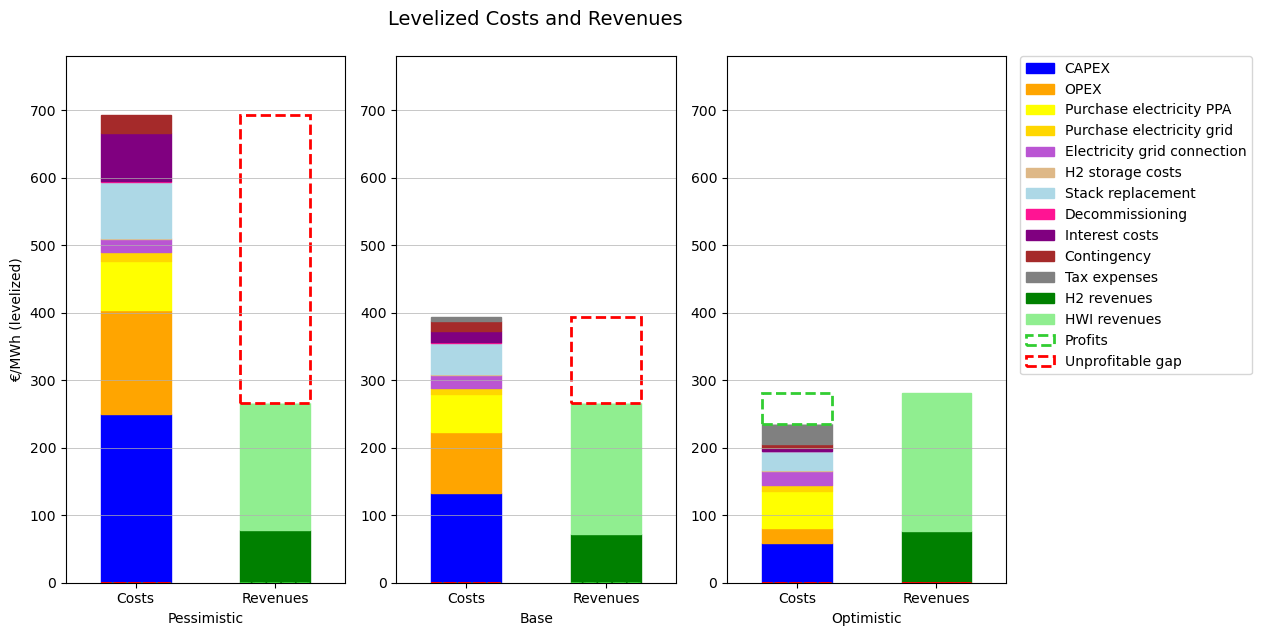

In [ ]:
import matplotlib.pyplot as plt

# Define specific colors for each variable
color_mapping = {
    'CAPEX': 'blue',
    'OPEX': 'orange',
    'Purchase electricity PPA': 'yellow',
    'Purchase electricity grid': 'gold', 
    'Electricity grid connection': 'mediumorchid',
    'H2 storage costs': 'burlywood', 
    'Stack replacement': 'lightblue', 
    'Decommissioning': '#FF1493',
    'Interest costs': 'purple',
    'Contingency': 'brown',
    'Tax expenses': 'grey',
    'H2 revenues': 'green',
    'HWI revenues': 'lightgreen',  
    'Profits': 'limegreen',
    'Unprofitable gap': 'red'  
}

# Plot levelized costs and revenues
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))
# plt.suptitle('Levelized Costs and Revenues')

# List of axes
axes = [ax1, ax2, ax3]

# Get column names
column_names = t_df_lcr_all_scenarios.columns

# Plot each scenario and apply custom colors
for ax, scenario in zip(axes, ['Pessimistic', 'Most likely', 'Optimistic']):
    xlabel = 'Base' if scenario == 'Most likely' else scenario
    plot = t_df_lcr_all_scenarios.loc[scenario].plot(
        kind='bar', stacked=True, ax=ax, rot='horizontal', legend=False,
        xlabel=xlabel, ylabel='€/MWh (levelized)' if ax == ax1 else None
    )
    
    # Iterate through bars and assign colors based on the variable name
    for i, bar in enumerate(ax.containers):
        for patch in bar:
            col_name = column_names[i]  # Get the corresponding column name
            
            if col_name == 'Unprofitable gap':  # Apply dashed line for 'Unprofitable gap'
                patch.set_edgecolor('red')  # Set edge color for the outline
                patch.set_linestyle('--')    # Set the edge line to dashed
                patch.set_linewidth(2)      # Make the dashed line thicker for visibility
                patch.set_facecolor('white')  # Set the fill color to white to only show outline
            elif col_name == "Profits":
                patch.set_edgecolor('limegreen')  # Set edge color for the outline
                patch.set_linestyle('--')    # Set the edge line to dashed
                patch.set_linewidth(2)      # Make the dashed line thicker for visibility
                patch.set_facecolor('white')  # Set the fill color to white to only show outline
            else:
                # Use the color mapping for other variables
                patch.set_color(color_mapping.get(col_name, 'gray'))  # Default to gray if not found

# Add a custom title above the "Most likely" plot
fig.text(0.36, 1.02, 'Levelized Costs and Revenues', ha='center', va='bottom', fontsize=14)


# Add a single legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Apply grid and y-limit to all axes
for ax in axes:
    ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.5)
    ax.set_ylim(0,780)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make space for the legend
plt.show()


Combined offshore + onshore figure for D3.4

In [8]:
off_el_lc = t_df_lcr_all_scenarios

In [9]:
off_el_lc = off_el_lc.loc[off_el_lc.index.get_level_values('Type') != 'Revenues']  # Filter out rows where 'Type' is 'Revenues'
off_el_lc = off_el_lc.drop(columns=['Unprofitable gap', 'Profits', 'H2 revenues', 'HWI revenues'])

In [10]:
off_el_lc

,,CAPEX,OPEX,Purchase electricity PPA,Purchase electricity grid,Electricity grid connection,H2 storage costs,Stack replacement,Decommissioning,Interest costs,Contingency,Tax expenses
Scenario,Type,,,,,,,,,,,
Pessimistic,Costs,249.264738,153.922196,73.282208,12.961826,19.640697,0.956481,82.943356,2.097438,71.053153,26.722785,-0.0
Most likely,Costs,133.228979,89.528547,56.069565,9.42917,20.087766,1.381003,45.816732,0.786244,16.570293,14.884046,5.721349
Optimistic,Costs,59.008617,21.973574,55.45203,8.099614,21.032239,1.587727,28.084523,0.51781,3.305986,6.113787,29.780124


In [11]:
on_el_lc = pd.read_pickle('on_el_lc.pkl')  # Load the DataFrame

In [12]:
on_el_lc = on_el_lc.loc[on_el_lc.index.get_level_values('Type') != 'Revenues']  # Filter out rows where 'Type' is 'Revenues'
on_el_lc = on_el_lc.drop(columns=['Unprofitable gap', 'Profits', 'H2 revenues', 'HWI revenues'])    

In [13]:
on_el_lc

,,CAPEX,OPEX,Purchase electricity PPA,Purchase electricity grid,Electricity grid connection,H2 storage costs,Entry tariff H2 network,Electricity tax,Stack replacement,Decommissioning,Interest costs,Contingency,Tax expenses
Scenario,Type,,,,,,,,,,,,,
Pessimistic,Costs,95.356637,27.640859,73.282208,12.961826,49.101744,0.956481,3.59501,3.900526,20.656721,0.802378,19.636366,10.222845,9.412289
Most likely,Costs,80.725026,22.606288,56.069565,9.42917,50.219416,1.381003,3.676841,3.989311,19.075811,0.476394,10.040138,9.018421,16.972885
Optimistic,Costs,41.464571,16.265512,55.45203,8.099614,52.580597,1.587727,3.849716,4.176878,14.072939,0.363858,2.646406,4.296077,26.451781


In [14]:
# Begin met kolomvolgorde van on_el_lc
on_columns = list(on_el_lc.columns)

# Voeg kolommen uit on_el_lc toe die nog niet in on_el_lc zitten
additional_columns = [col for col in off_el_lc.columns if col not in on_columns]

# Combineer de lijst zonder te sorteren
all_columns = on_columns + additional_columns

# Vul ontbrekende kolommen aan met nullen
off_el_lc_filled = off_el_lc.reindex(columns=all_columns, fill_value=0)
on_el_lc_filled = on_el_lc.reindex(columns=all_columns, fill_value=0)


In [15]:
off_el_lc_filled

,,CAPEX,OPEX,Purchase electricity PPA,Purchase electricity grid,Electricity grid connection,H2 storage costs,Entry tariff H2 network,Electricity tax,Stack replacement,Decommissioning,Interest costs,Contingency,Tax expenses
Scenario,Type,,,,,,,,,,,,,
Pessimistic,Costs,249.264738,153.922196,73.282208,12.961826,19.640697,0.956481,0,0,82.943356,2.097438,71.053153,26.722785,-0.0
Most likely,Costs,133.228979,89.528547,56.069565,9.42917,20.087766,1.381003,0,0,45.816732,0.786244,16.570293,14.884046,5.721349
Optimistic,Costs,59.008617,21.973574,55.45203,8.099614,21.032239,1.587727,0,0,28.084523,0.51781,3.305986,6.113787,29.780124


In [16]:
on_el_lc_filled

,,CAPEX,OPEX,Purchase electricity PPA,Purchase electricity grid,Electricity grid connection,H2 storage costs,Entry tariff H2 network,Electricity tax,Stack replacement,Decommissioning,Interest costs,Contingency,Tax expenses
Scenario,Type,,,,,,,,,,,,,
Pessimistic,Costs,95.356637,27.640859,73.282208,12.961826,49.101744,0.956481,3.59501,3.900526,20.656721,0.802378,19.636366,10.222845,9.412289
Most likely,Costs,80.725026,22.606288,56.069565,9.42917,50.219416,1.381003,3.676841,3.989311,19.075811,0.476394,10.040138,9.018421,16.972885
Optimistic,Costs,41.464571,16.265512,55.45203,8.099614,52.580597,1.587727,3.849716,4.176878,14.072939,0.363858,2.646406,4.296077,26.451781


The figure from D3.4 is made below, but make sure to set start year to 2040 and offshore electrolysis to 500MW

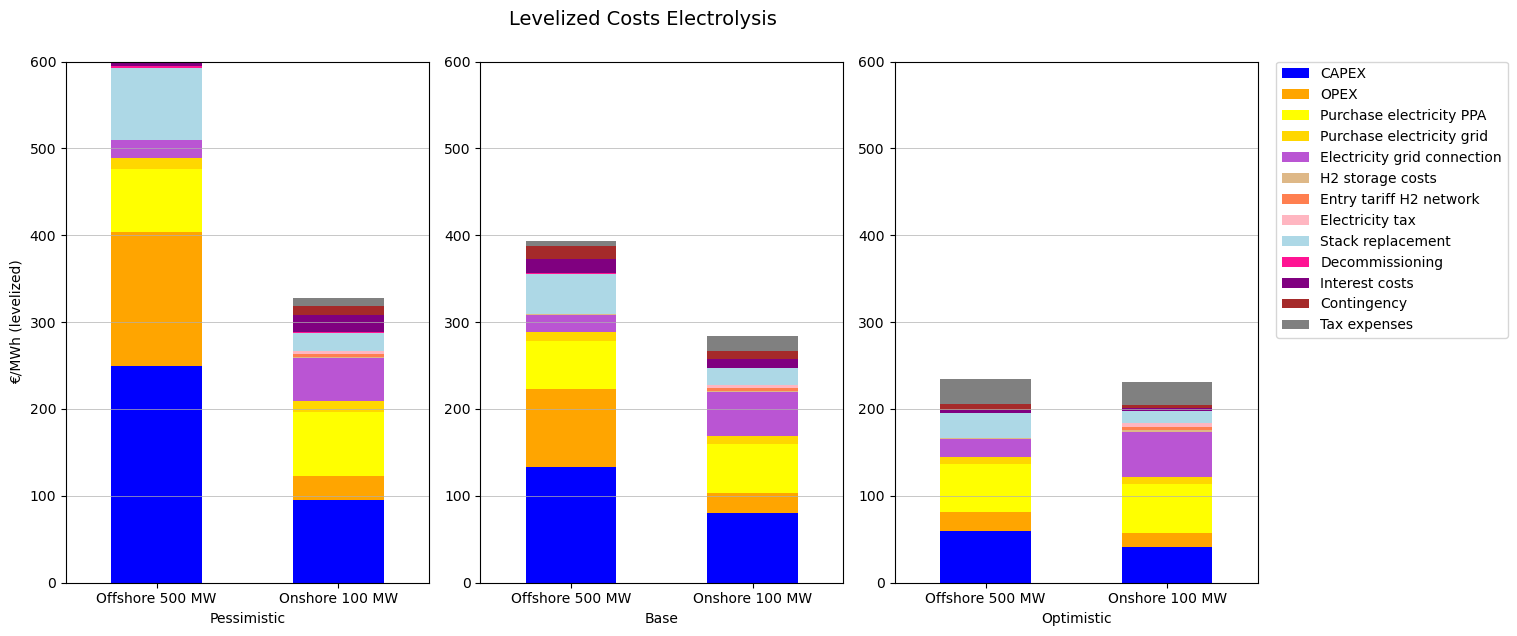

In [17]:
import matplotlib.pyplot as plt

# Define specific colors for each variable
color_mapping = {
    'CAPEX': 'blue',
    'OPEX': 'orange',
    'Purchase electricity PPA': 'yellow',
    'Purchase electricity grid': 'gold', 
    'Electricity grid connection': 'mediumorchid',
    'H2 storage costs': 'burlywood', 
    'Stack replacement': 'lightblue', 
    'Decommissioning': '#FF1493',
    'Interest costs': 'purple',
    'Contingency': 'brown',
    'Tax expenses': 'grey',
    'Entry tariff H2 network': 'coral',
    'Electricity tax': 'lightpink',  
    'Profits': 'limegreen',
    'Unprofitable gap': 'red'  
}

# Plot levelized costs and revenues
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))  # Iets breder ivm dubbele bars
axes = [ax1, ax2, ax3]

# Plot each scenario
for ax, scenario in zip(axes, ['Pessimistic', 'Most likely', 'Optimistic']):
    xlabel = 'Base' if scenario == 'Most likely' else scenario

    # Combine both datasets
    df_off = off_el_lc_filled.loc[[scenario]].rename(index={scenario: 'Offshore'})
    df_on = on_el_lc_filled.loc[[scenario]].rename(index={scenario: 'Onshore'})
    combined = pd.concat([df_off, df_on], axis=0)

    # Kleurvolgorde afleiden
    colors = [color_mapping.get(col, 'gray') for col in combined.columns]

    # Plot met aangepaste kleurvolgorde
    combined.plot(
        kind='bar', stacked=True, ax=ax, rot=0, legend=False,
        xlabel=xlabel, ylabel='€/MWh (levelized)' if ax == ax1 else None,
        color=colors
    )

    # Zet labels op x-as ('Offshore', 'Onshore')
    ax.set_xticklabels(['Offshore 500 MW', 'Onshore 100 MW'], rotation=0)

# Titel boven 'Most likely'
fig.text(0.36, 1.02, 'Levelized Costs Electrolysis', ha='center', va='bottom', fontsize=14)

# Legenda buiten de figuur
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Grid en y-lim
for ax in axes:
    ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.5)
    ax.set_ylim(0, 600)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()
